In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import cv2
import random
import kagglehub
import glob
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

# 1. 캐글 데이터 다운로드 및 경로 설정
path = kagglehub.dataset_download("andrewmvd/drive-digital-retinal-images-for-vessel-extraction")
DATA_DIR = path

all_tifs = sorted(glob.glob(os.path.join(DATA_DIR, "**/*.tif"), recursive=True))
all_gifs = sorted(glob.glob(os.path.join(DATA_DIR, "**/*.gif"), recursive=True))

train_img_paths = sorted([p for p in all_tifs if 'training' in p.lower()])
train_mask_paths = sorted([p for p in all_gifs if 'training' in p.lower()])
test_img_paths = sorted([p for p in all_tifs if 'test' in p.lower()])
test_mask_paths = sorted([p for p in all_gifs if 'test' in p.lower()])

print(f"✅ 데이터 로드 완료: Train {len(train_img_paths)}장, Test {len(test_img_paths)}장")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Using Colab cache for faster access to the 'drive-digital-retinal-images-for-vessel-extraction' dataset.
✅ 데이터 로드 완료: Train 20장, Test 20장


In [ ]:
class RetinalPatchDataset(Dataset):
    def __init__(self, img_paths, mask_paths, patch_size=256, samples_per_epoch=1000, transform=None):
        self.patch_size = patch_size
        self.samples_per_epoch = samples_per_epoch
        self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        self.images, self.masks = [], []

        for img_p, mask_p in zip(img_paths, mask_paths):
            img = cv2.imread(img_p)
            enhanced = self.clahe.apply(img[:, :, 1]) # Green Ch + CLAHE
            self.images.append(cv2.merge([enhanced]*3))
            mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
            self.masks.append((mask > 127).astype(np.uint8))

    def __len__(self): return self.samples_per_epoch

    def __getitem__(self, idx):
        img_idx = random.randint(0, len(self.images) - 1)
        img, mask = self.images[img_idx], self.masks[img_idx]
        h, w = img.shape[:2]

        # 50% 확률로 혈관 중심 크롭
        if random.random() > 0.5:
            v_y, v_x = np.where(mask == 1)
            if len(v_y) > 0:
                ii = random.randint(0, len(v_y)-1)
                y = min(max(v_y[ii] - self.patch_size//2, 0), h - self.patch_size)
                x = min(max(v_x[ii] - self.patch_size//2, 0), w - self.patch_size)
            else:
                y, x = random.randint(0, h-self.patch_size), random.randint(0, w-self.patch_size)
        else:
            y, x = random.randint(0, h-self.patch_size), random.randint(0, w-self.patch_size)

        img_p, mask_p = img[y:y+self.patch_size, x:x+self.patch_size], mask[y:y+self.patch_size, x:x+self.patch_size]
        if self.transform:
            augmented = self.transform(image=img_p, mask=mask_p)
            img_p, mask_p = augmented['image'], augmented['mask']
        return img_p, mask_p.long()

# 증강 설정
train_tf = A.Compose([A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.Normalize(), ToTensorV2()])
train_loader = DataLoader(RetinalPatchDataset(train_img_paths, train_mask_paths, transform=train_tf), batch_size=8, shuffle=True)

In [ ]:
def get_plwce_weights(img_paths, mask_paths, alpha=4.0):
    bg, fg = 0, 0
    for p in mask_paths:
        m = np.array(Image.open(p))
        fg += (m > 127).sum(); bg += (m <= 127).sum()
    counts = np.array([bg, fg], dtype=np.float32)
    weights = 1.0 / np.power(np.log1p(counts), alpha)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32).to(device)

class PLWCE_DiceLoss(nn.Module):
    def __init__(self, weights, smooth=1e-6):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weights)
        self.smooth = smooth

    def forward(self, logits, targets):
        # 1. CE Loss (PLWCE)
        ce_loss = self.ce(logits, targets)

        # 2. Dice Loss
        probs = F.softmax(logits, dim=1)[:, 1, :, :] # 혈관 클래스(1) 확률
        targets_f = targets.float()

        intersection = (probs * targets_f).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (probs.sum() + targets_f.sum() + self.smooth)

        # 두 손실의 합
        return ce_loss + dice_loss

# 가중치 계산 후 새로운 Loss 함수 적용
criterion = PLWCE_DiceLoss(weights)

weights = get_plwce_weights(train_img_paths, train_mask_paths, alpha=3.0)
criterion = PLWCELoss(weights)
print(f"✅ 가중치 계산 완료: {weights}")

✅ 가중치 계산 완료: tensor([0.9561, 1.0439], device='cuda:0')


In [ ]:
# --- 1. IterNet ---
class IterNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.Conv2d(32, 32, 3, 1, 1), nn.ReLU())
        self.out = nn.Conv2d(32, 1, 1)
        self.iter = nn.Sequential(nn.Conv2d(33, 32, 3, 1, 1), nn.ReLU(), nn.Conv2d(32, 1, 1))
    def forward(self, x):
        feat = self.base(x)
        out1 = self.out(feat)
        out2 = self.iter(torch.cat([feat, out1], dim=1))
        return [out1, out2]

# --- 2. PraNet 패치 및 로드 ---
if not os.path.exists('/content/PraNet'):
    !git clone https://github.com/DengPingFan/PraNet.git
sys.path.append('/content/PraNet/lib')
from PraNet_Res2Net import PraNet

iternet_model = IterNet().to(device)
pranet_model = PraNet().to(device)
print("✅ 두 모델 로드 완료")

✅ 두 모델 로드 완료


In [ ]:
def train_model(model, name, epochs=20):
    opt = optim.Adam(model.parameters(), lr=1e-4)
    print(f"🔥 {name} 학습 시작...")

    for epoch in range(epochs):
        model.train()
        l_sum = 0
        for imgs, masks in tqdm(train_loader, desc=f"Ep {epoch+1}"):
            imgs, masks = imgs.to(device), masks.to(device)
            opt.zero_grad()

            preds = model(imgs)
            loss = 0

            # 1. 여러 개의 출력을 내보내는 경우 (IterNet: list, PraNet: tuple)
            if isinstance(preds, (list, tuple)):
                for p in preds:
                    # 마스크 크기에 맞춰 보간
                    p = F.interpolate(p, size=masks.shape[1:], mode='bilinear', align_corners=True)
                    # 1채널을 2채널 로짓으로 변환 (PLWCE 적용용)
                    logits = torch.cat([torch.zeros_like(p), p], dim=1)
                    loss += criterion(logits, masks)

            # 2. 단일 출력을 내보내는 경우
            else:
                p = F.interpolate(preds, size=masks.shape[1:], mode='bilinear', align_corners=True)
                logits = torch.cat([torch.zeros_like(p), p], dim=1)
                loss = criterion(logits, masks)

            loss.backward()
            opt.step()
            l_sum += loss.item()

        print(f"[{name}] Epoch {epoch+1} Loss: {l_sum/len(train_loader):.4f}")

# 다시 학습 실행
train_model(iternet_model, "IterNet")
train_model(pranet_model, "PraNet")

🔥 IterNet 학습 시작...


Ep 1: 100%|██████████| 125/125 [00:05<00:00, 21.19it/s]


[IterNet] Epoch 1 Loss: 1.0372


Ep 2: 100%|██████████| 125/125 [00:05<00:00, 21.16it/s]


[IterNet] Epoch 2 Loss: 0.7615


...

[PraNet] Epoch 18 Loss: 1.0126


Ep 19: 100%|██████████| 125/125 [00:23<00:00,  5.25it/s]


[PraNet] Epoch 19 Loss: 1.0006


Ep 20: 100%|██████████| 125/125 [00:23<00:00,  5.27it/s]

[PraNet] Epoch 20 Loss: 0.9935


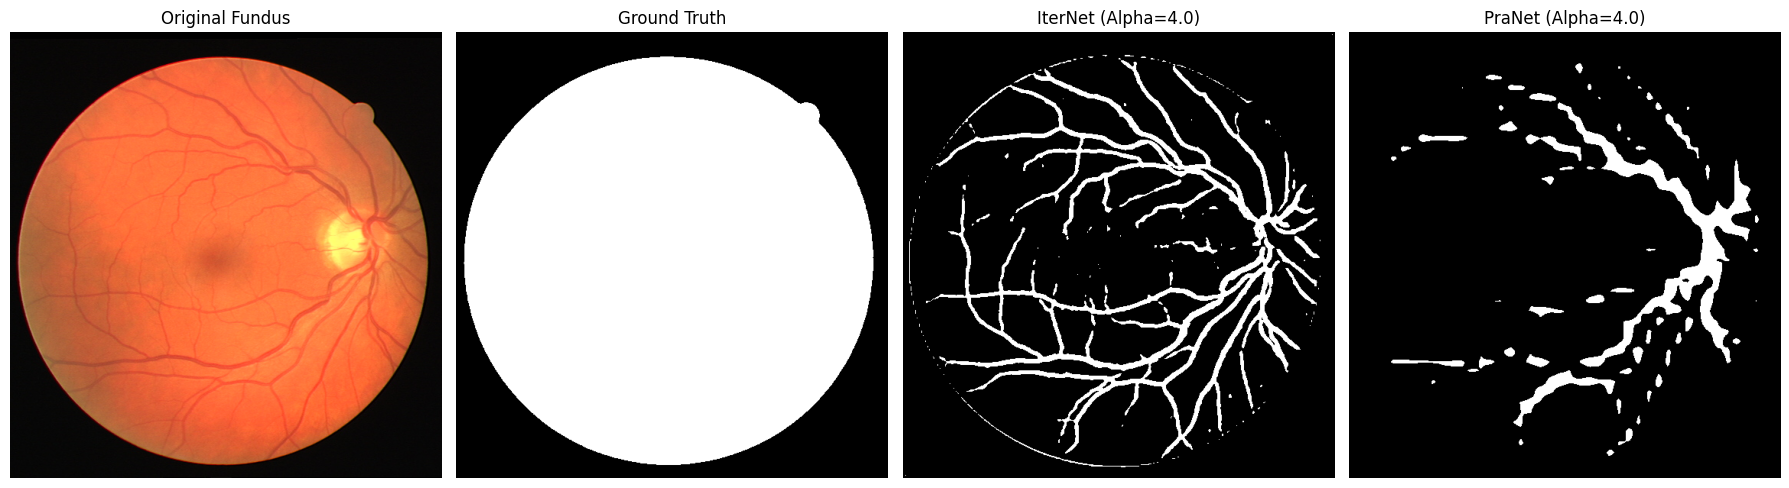

In [ ]:
def fast_predict_fixed(model, img_path, target_size=352):
    model.eval()
    img = cv2.imread(img_path)
    h_orig, w_orig = img.shape[:2]

    # 전처리: Green Ch + CLAHE
    green = cv2.createCLAHE(clipLimit=2.0).apply(img[:, :, 1])
    resized = cv2.resize(cv2.merge([green]*3), (target_size, target_size))

    # ✅ 중요: 학습과 동일한 Normalize 적용
    transform = A.Compose([
        A.Normalize(), # default는 ImageNet stats (mean=0.485, 0.456, 0.406 / std=0.229, 0.224, 0.225)
        ToTensorV2()
    ])
    input_tensor = transform(image=resized)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(input_tensor)
        res = preds[-1] if isinstance(preds, (list, tuple)) else preds
        res_resized = F.interpolate(res, size=(h_orig, w_orig), mode='bilinear', align_corners=True)

        # Sigmoid를 통과시켜 0~1 사이 확률값으로 변환
        return torch.sigmoid(res_resized).squeeze().cpu().numpy()

# ----------------------------------------------------------------------
# 결과 시각화 및 비교
# ----------------------------------------------------------------------
idx = 1  # 첫 번째 테스트 이미지
it_res = fast_predict_fixed(iternet_model, test_img_paths[idx])
pr_res = fast_predict_fixed(pranet_model, test_img_paths[idx])
gt = cv2.imread(test_mask_paths[idx], 0) / 255.0

plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(cv2.imread(test_img_paths[idx]), cv2.COLOR_BGR2RGB))
plt.title("Original Fundus")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(it_res > 0.5, cmap='gray')
plt.title(f"IterNet (Alpha={4.0})")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(pr_res > 0.5, cmap='gray')
plt.title(f"PraNet (Alpha={4.0})")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def calculate_dice(pred, target):
    pred = (pred > 0.5).astype(np.float32)
    target = (target > 0.5).astype(np.float32)
    intersection = (pred * target).sum()
    dice = (2. * intersection) / (pred.sum() + target.sum() + 1e-8)
    return dice

it_dice_list = []
pr_dice_list = []

for idx in range(len(test_img_paths)):
    gt = cv2.imread(test_mask_paths[idx], 0) / 255.0

    it_res = fast_predict_fixed(iternet_model, test_img_paths[idx])
    pr_res = fast_predict_fixed(pranet_model, test_img_paths[idx])

    it_dice_list.append(calculate_dice(it_res, gt))
    pr_dice_list.append(calculate_dice(pr_res, gt))

print("\n[최종 평가지표 결과]")
print(f"IterNet (Alpha=4.0) Dice Score: {np.mean(it_dice_list):.4f}")
print(f"PraNet  (Alpha=4.0) Dice Score: {np.mean(pr_dice_list):.4f}")


[최종 평가지표 결과]
IterNet (Alpha=4.0) Dice Score: 0.2094
PraNet  (Alpha=4.0) Dice Score: 0.1271


In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix

def evaluate_comprehensive(model, img_paths, mask_paths, name="Model"):
    dices, accs, sens, spes, aucs = [], [], [], [], []

    print(f" {name} 종합 평가 중...")
    for idx in tqdm(range(len(img_paths))):
        gt = (cv2.imread(mask_paths[idx], 0) > 127).astype(np.uint8)

        # 모델 예측 (확률값 0~1)
        prob = fast_predict_fixed(model, img_paths[idx])
        pred = (prob > 0.5).astype(np.uint8)

        # 1. AUC-ROC (임계값에 무관한 성능)
        aucs.append(roc_auc_score(gt.flatten(), prob.flatten()))

        # 2. Confusion Matrix 요소 추출
        tn, fp, fn, tp = confusion_matrix(gt.flatten(), pred.flatten()).ravel()

        # 3. 지표 계산
        dice = (2. * tp) / (2. * tp + fp + fn + 1e-8)
        acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
        sen = tp / (tp + fn + 1e-8)  # Sensitivity (혈관을 얼마나 잘 찾았나)
        spe = tn / (tn + fp + 1e-8)  # Specificity (배경을 얼마나 잘 찾았나)

        dices.append(dice); accs.append(acc); sens.append(sen); spes.append(spe)

    print(f"\n [{name} 최종 리포트]")
    print(f" - Dice (F1-Score): {np.mean(dices):.4f}")
    print(f" - Accuracy      : {np.mean(accs):.4f}")
    print(f" - Sensitivity   : {np.mean(sens):.4f} (혈관 검출력)")
    print(f" - Specificity   : {np.mean(spes):.4f} (배경 보호력)")
    print(f" - AUC-ROC       : {np.mean(aucs):.4f} (종합 분류능력)")
    return np.mean(dices)

# 실행
it_score = evaluate_comprehensive(iternet_model, test_img_paths, test_mask_paths, "IterNet")
pr_score = evaluate_comprehensive(pranet_model, test_img_paths, test_mask_paths, "PraNet")

 IterNet 종합 평가 중...


100%|██████████| 20/20 [00:02<00:00,  8.81it/s]



 [IterNet 최종 리포트]
 - Dice (F1-Score): 0.2094
 - Accuracy      : 0.3903
 - Sensitivity   : 0.1177 (혈관 검출력)
 - Specificity   : 0.9905 (배경 보호력)
 - AUC-ROC       : 0.8887 (종합 분류능력)
 PraNet 종합 평가 중...


100%|██████████| 20/20 [00:02<00:00,  7.67it/s]


 [PraNet 최종 리포트]
 - Dice (F1-Score): 0.1271
 - Accuracy      : 0.3591
 - Sensitivity   : 0.0680 (혈관 검출력)
 - Specificity   : 1.0000 (배경 보호력)
 - AUC-ROC       : 0.9589 (종합 분류능력)
